# Healthcare Provider Fraud Detection - Modeling

## Objective
Build and compare multiple machine learning models to detect fraudulent healthcare providers.

**Key Challenges:**
- Severe class imbalance (~10% fraud)
- Need for interpretability
- Minimizing false positives (unnecessary investigations)
- Maximizing recall (catching fraudsters)

**Models to Compare:**
1. Logistic Regression (baseline, interpretable)
2. Random Forest (robust, feature importance)
3. XGBoost (high performance, handles imbalance well)

## 1. Import Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and splitting
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler

# Class imbalance handling
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation metrics
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay
)

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Style settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 2. Load Data

We'll load the preprocessed data from the feature engineering notebook.
This dataset contains provider-level aggregated features.

**Note:** If you're running this in Google Colab, the next cell will prompt you to upload the CSV file.
If you're running locally, make sure the file `01_X_y_for_modeling.csv` is in the same directory as this notebook.

In [2]:
# Check if we're in Colab and handle file loading
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab environment")
except:
    IN_COLAB = False
    print("Running in local environment")

if IN_COLAB:
    # File is expected to be in the Colab environment directly.
    print("Please ensure '01_X_y_for_modeling.csv' is accessible in the Colab filesystem (e.g., /content/).")
else:
    print("If running locally, ensure '01_X_y_for_modeling.csv' is in the current directory.")

Running in Google Colab environment
Please ensure '01_X_y_for_modeling.csv' is accessible in the Colab filesystem (e.g., /content/).


In [3]:
# Load the preprocessed data
# For Colab: Update this path to your Google Drive location after mounting
# Example: '/content/drive/MyDrive/ML/project2/01_X_y_for_modeling.csv'
file_path = '/content/01_X_y_for_modeling.csv'  # Updated path for Colab environment

df = pd.read_csv(file_path)

print(f"Dataset shape: {df.shape}")
print(f"Number of features: {df.shape[1] - 1}")
print(f"Number of providers: {df.shape[0]}")
print("\nFirst few rows:")
df.head()

Dataset shape: (5410, 25)
Number of features: 24
Number of providers: 5410

First few rows:


,PotentialFraud,Total_Claims,Total_Cost,Total_Patients,AvgCost_PerClaim,Cost_PerPatient,Claims_PerPatient,Inp_Claims,Inp_TotalCost,Inp_AvgCost,...,Inp_Out_ClaimRatio,Inp_Out_CostRatio,Inp_AvgAge,Out_AvgAge,Inp_AvgChronicConditions,Out_AvgChronicConditions,Inp_NumUniquePatients,Out_NumUniquePatients,Has_HighInpatientCost,Has_ExtremeTotalCost
0,0,25.0,104640.0,24.0,4185.600000,4360.000000,1.041667,5.0,97000.0,19400.000000,...,0.238095,12.694673,94.464613,94.802738,16.000000,16.550000,5.0,19.0,0,0
1,1,132.0,605670.0,119.0,4588.409091,5089.663866,1.109244,62.0,573000.0,9241.935484,...,0.873239,17.538490,86.790135,85.262384,17.080645,17.785714,53.0,66.0,1,0
2,0,149.0,52170.0,138.0,350.134228,378.043478,1.079710,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,88.161919,0.000000,17.657718,0.0,138.0,0,0
3,1,1165.0,280910.0,495.0,241.124464,567.494949,2.353535,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,86.442121,0.000000,17.664378,0.0,495.0,0,0
4,0,72.0,33710.0,59.0,468.194444,571.355932,1.220339,3.0,19000.0,6333.333333,...,0.042857,1.291551,94.731462,84.802865,16.333333,17.898551,3.0,56.0,0,0


In [4]:
# Check data info
print("Dataset Info:")
df.info()

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5410 entries, 0 to 5409
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   PotentialFraud            5410 non-null   int64  
 1   Total_Claims              5410 non-null   float64
 2   Total_Cost                5410 non-null   float64
 3   Total_Patients            5410 non-null   float64
 4   AvgCost_PerClaim          5410 non-null   float64
 5   Cost_PerPatient           5410 non-null   float64
 6   Claims_PerPatient         5410 non-null   float64
 7   Inp_Claims                5410 non-null   float64
 8   Inp_TotalCost             5410 non-null   float64
 9   Inp_AvgCost               5410 non-null   float64
 10  Inp_MaxCost               5410 non-null   float64
 11  Inp_AvgLengthOfStay       5410 non-null   float64
 12  Out_Claims                5410 non-null   float64
 13  Out_TotalCost             5410 non-null   float64

## 3. Understand Class Distribution

**Class Imbalance** is when one class significantly outnumbers the other.
This is common in fraud detection where fraudulent cases are rare.

**Why it matters:** Models trained on imbalanced data tend to predict the majority class, achieving high accuracy but missing the minority class (fraud).

Class Distribution:
PotentialFraud
0    4904
1     506
Name: count, dtype: int64

Class Proportions:
PotentialFraud
0    0.90647
1    0.09353
Name: proportion, dtype: float64


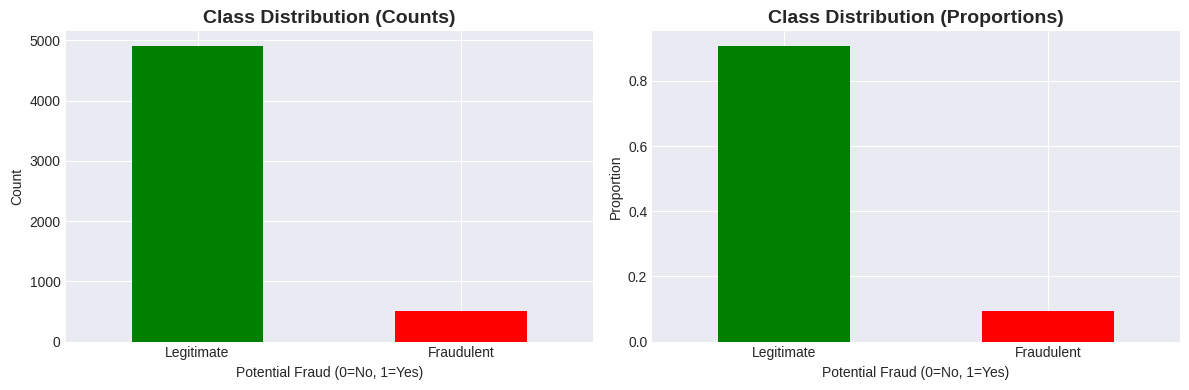


⚠️ Imbalance Ratio: 9.69:1 (Legitimate:Fraudulent)
This means for every 1 fraudulent provider, there are 10 legitimate providers.


In [5]:
# Check class distribution
print("Class Distribution:")
print(df['PotentialFraud'].value_counts())
print("\nClass Proportions:")
print(df['PotentialFraud'].value_counts(normalize=True))

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
df['PotentialFraud'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Class Distribution (Counts)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Potential Fraud (0=No, 1=Yes)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Legitimate', 'Fraudulent'], rotation=0)

# Percentage plot
df['PotentialFraud'].value_counts(normalize=True).plot(kind='bar', ax=axes[1], color=['green', 'red'])
axes[1].set_title('Class Distribution (Proportions)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Potential Fraud (0=No, 1=Yes)')
axes[1].set_ylabel('Proportion')
axes[1].set_xticklabels(['Legitimate', 'Fraudulent'], rotation=0)

plt.tight_layout()
plt.show()

# Calculate imbalance ratio
fraud_count = df['PotentialFraud'].sum()
legit_count = len(df) - fraud_count
imbalance_ratio = legit_count / fraud_count
print(f"\n⚠️ Imbalance Ratio: {imbalance_ratio:.2f}:1 (Legitimate:Fraudulent)")
print(f"This means for every 1 fraudulent provider, there are {imbalance_ratio:.0f} legitimate providers.")

In [6]:
print(df.columns.tolist())

['PotentialFraud', 'Total_Claims', 'Total_Cost', 'Total_Patients', 'AvgCost_PerClaim', 'Cost_PerPatient', 'Claims_PerPatient', 'Inp_Claims', 'Inp_TotalCost', 'Inp_AvgCost', 'Inp_MaxCost', 'Inp_AvgLengthOfStay', 'Out_Claims', 'Out_TotalCost', 'Out_AvgCost', 'Inp_Out_ClaimRatio', 'Inp_Out_CostRatio', 'Inp_AvgAge', 'Out_AvgAge', 'Inp_AvgChronicConditions', 'Out_AvgChronicConditions', 'Inp_NumUniquePatients', 'Out_NumUniquePatients', 'Has_HighInpatientCost', 'Has_ExtremeTotalCost']


## 4. Prepare Features and Target

Separate the dataset into:
- **X**: Feature matrix (all columns except target)
- **y**: Target vector (PotentialFraud)

In [7]:
# Separate features and target
X = df.drop('PotentialFraud', axis=1)
y = df['PotentialFraud']

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"\nFeature names:")
print(X.columns.tolist())

Feature matrix shape: (5410, 24)
Target vector shape: (5410,)

Feature names:
['Total_Claims', 'Total_Cost', 'Total_Patients', 'AvgCost_PerClaim', 'Cost_PerPatient', 'Claims_PerPatient', 'Inp_Claims', 'Inp_TotalCost', 'Inp_AvgCost', 'Inp_MaxCost', 'Inp_AvgLengthOfStay', 'Out_Claims', 'Out_TotalCost', 'Out_AvgCost', 'Inp_Out_ClaimRatio', 'Inp_Out_CostRatio', 'Inp_AvgAge', 'Out_AvgAge', 'Inp_AvgChronicConditions', 'Out_AvgChronicConditions', 'Inp_NumUniquePatients', 'Out_NumUniquePatients', 'Has_HighInpatientCost', 'Has_ExtremeTotalCost']


## 5. Train/Validation/Test Split

**Why split into 3 sets?**
- **Training Set (60%)**: Model learns patterns from this data
- **Validation Set (20%)**: Tune hyperparameters and select best model
- **Test Set (20%)**: Final evaluation on completely unseen data

**Critical Rule:** NEVER look at the test set until final evaluation!

**Stratification:** Ensures each split has the same proportion of fraud/legitimate cases

In [8]:
# First split: separate test set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for test
    stratify=y,         # Maintain class proportions
    random_state=RANDOM_STATE
)

# Second split: split remaining into train (60% of total) and validation (20% of total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,     # 0.25 * 0.8 = 0.2 (20% of total)
    stratify=y_temp,
    random_state=RANDOM_STATE
)

print("Dataset Split Summary:")
print(f"Training set:   {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set:       {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

# Verify class distribution in each split
print("\nClass Distribution in Each Split:")
print(f"Training:   Fraud={y_train.sum()}/{len(y_train)} ({y_train.sum()/len(y_train)*100:.1f}%)")
print(f"Validation: Fraud={y_val.sum()}/{len(y_val)} ({y_val.sum()/len(y_val)*100:.1f}%)")
print(f"Test:       Fraud={y_test.sum()}/{len(y_test)} ({y_test.sum()/len(y_test)*100:.1f}%)")

Dataset Split Summary:
Training set:   3246 samples (60.0%)
Validation set: 1082 samples (20.0%)
Test set:       1082 samples (20.0%)

Class Distribution in Each Split:
Training:   Fraud=304/3246 (9.4%)
Validation: Fraud=101/1082 (9.3%)
Test:       Fraud=101/1082 (9.3%)


## 6. Feature Scaling

**Why scale?** Many ML algorithms (Logistic Regression, SVM) are sensitive to feature magnitude.

**StandardScaler:** Transforms features to have mean=0 and std=1
- Formula: z = (x - mean) / std

**Important:** Fit scaler ONLY on training data, then transform all sets.
This prevents data leakage from validation/test sets.

In [9]:
# Initialize scaler
scaler = StandardScaler()

# Fit on training data only
X_train_scaled = scaler.fit_transform(X_train)

# Transform validation and test using training statistics
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrames to keep column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("✓ Feature scaling completed")
print(f"\nExample - Before scaling (first row):")
print(X_train.iloc[0].head())
print(f"\nAfter scaling (first row):")
print(X_train_scaled.iloc[0].head())

✓ Feature scaling completed

Example - Before scaling (first row):
Total_Claims            71.000000
Total_Cost          178930.000000
Total_Patients          59.000000
AvgCost_PerClaim      2520.140845
Cost_PerPatient       3032.711864
Name: 3143, dtype: float64

After scaling (first row):
Total_Claims       -0.114381
Total_Cost          0.279931
Total_Patients     -0.049962
AvgCost_PerClaim    0.217982
Cost_PerPatient     0.280001
Name: 0, dtype: float64


## 7. Handling Class Imbalance

We'll compare different strategies:

### Strategy 1: Class Weighting
- Assigns higher weight to minority class (fraud)
- Model penalizes misclassifying fraud more heavily
- **Pros:** Simple, no data manipulation
- **Cons:** Less flexible than cost-sensitive approaches

### Strategy 2: SMOTE (Synthetic Minority Over-sampling Technique)
- Creates synthetic fraud examples by interpolating between existing fraud cases
- **How it works:** For each fraud case, find k nearest neighbors and create new points along the line connecting them
- **Pros:** Increases minority class samples, model sees more variety
- **Cons:** Can create noisy samples, computationally expensive

### Strategy 3: Random Under-sampling
- Randomly removes samples from majority class (legitimate providers)
- **Pros:** Fast, balanced dataset
- **Cons:** Loses potentially useful information

We'll apply SMOTE only to the training set!

In [10]:
# Apply SMOTE to training data
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:")
print(f"  Total samples: {len(y_train)}")
print(f"  Fraud: {y_train.sum()} ({y_train.sum()/len(y_train)*100:.1f}%)")
print(f"  Legitimate: {len(y_train) - y_train.sum()} ({(len(y_train) - y_train.sum())/len(y_train)*100:.1f}%)")

print("\nAfter SMOTE:")
print(f"  Total samples: {len(y_train_smote)}")
print(f"  Fraud: {y_train_smote.sum()} ({y_train_smote.sum()/len(y_train_smote)*100:.1f}%)")
print(f"  Legitimate: {len(y_train_smote) - y_train_smote.sum()} ({(len(y_train_smote) - y_train_smote.sum())/len(y_train_smote)*100:.1f}%)")

print("\n✓ SMOTE successfully balanced the training data")

Before SMOTE:
  Total samples: 3246
  Fraud: 304 (9.4%)
  Legitimate: 2942 (90.6%)

After SMOTE:
  Total samples: 5884
  Fraud: 2942 (50.0%)
  Legitimate: 2942 (50.0%)

✓ SMOTE successfully balanced the training data


## 8. Model Training and Evaluation

We'll train three models and compare their performance:

### Model 1: Logistic Regression (Baseline)
- Simple linear model
- Easy to interpret (coefficients show feature importance)
- Fast to train
- Good baseline for comparison

In [11]:
# Train Logistic Regression on SMOTE-balanced data
print("Training Logistic Regression...")
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    class_weight=None  # Not needed since we used SMOTE
)

lr_model.fit(X_train_smote, y_train_smote)
print("✓ Logistic Regression trained")

# Predictions on validation set
y_val_pred_lr = lr_model.predict(X_val_scaled)
y_val_pred_proba_lr = lr_model.predict_proba(X_val_scaled)[:, 1]

Training Logistic Regression...
✓ Logistic Regression trained


### Model 2: Random Forest
- Ensemble of decision trees
- Each tree trained on random subset of data and features
- Final prediction = majority vote of all trees
- **Pros:** Handles non-linear relationships, robust, provides feature importance
- **Cons:** Less interpretable than single tree, can be slow

In [12]:
# Train Random Forest on SMOTE-balanced data
print("Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100,           # Number of trees
    max_depth=10,                # Max depth of each tree (prevents overfitting)
    min_samples_split=10,        # Min samples to split a node
    min_samples_leaf=5,          # Min samples in leaf node
    random_state=RANDOM_STATE,
    n_jobs=-1                    # Use all CPU cores
)

rf_model.fit(X_train_smote, y_train_smote)
print("✓ Random Forest trained")

# Predictions on validation set
y_val_pred_rf = rf_model.predict(X_val_scaled)
y_val_pred_proba_rf = rf_model.predict_proba(X_val_scaled)[:, 1]

Training Random Forest...
✓ Random Forest trained


### Model 3: XGBoost (Extreme Gradient Boosting)
- Builds trees sequentially, each correcting errors of previous trees
- Uses gradient descent to minimize loss
- **Pros:** Usually best performance, handles imbalance well, built-in regularization
- **Cons:** More hyperparameters to tune, can overfit

**Key parameters:**
- `scale_pos_weight`: Balances positive/negative classes (alternative to SMOTE)
- `max_depth`: Controls tree complexity
- `learning_rate`: Controls how much each tree contributes (smaller = more robust)
- `n_estimators`: Number of boosting rounds

In [13]:
# Calculate scale_pos_weight for XGBoost
scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()
print(f"Scale pos weight: {scale_pos_weight:.2f}")

# Train XGBoost with class weighting (instead of SMOTE)
print("\nTraining XGBoost...")
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,  # Handle imbalance
    random_state=RANDOM_STATE,
    eval_metric='logloss'
)

# Train on original (non-SMOTE) data since we use scale_pos_weight
xgb_model.fit(X_train_scaled, y_train)
print("✓ XGBoost trained")

# Predictions on validation set
y_val_pred_xgb = xgb_model.predict(X_val_scaled)
y_val_pred_proba_xgb = xgb_model.predict_proba(X_val_scaled)[:, 1]

Scale pos weight: 9.68

Training XGBoost...
✓ XGBoost trained


## 9. Model Evaluation

### Evaluation Metrics for Imbalanced Data:

**Confusion Matrix:**
```
                Predicted
              Neg    Pos
Actual  Neg   TN     FP
        Pos   FN     TP
```

**Precision** = TP / (TP + FP)
- Of all predicted frauds, how many are actually fraud?
- High precision = fewer false alarms

**Recall (Sensitivity)** = TP / (TP + FN)
- Of all actual frauds, how many did we catch?
- High recall = catch more fraudsters

**F1-Score** = 2 × (Precision × Recall) / (Precision + Recall)
- Harmonic mean of precision and recall
- Balances both metrics

**ROC-AUC:** Area under ROC curve (plots True Positive Rate vs False Positive Rate)

**PR-AUC:** Area under Precision-Recall curve (better for imbalanced data)

In [14]:
def evaluate_model(y_true, y_pred, y_pred_proba, model_name):
    """
    Comprehensive evaluation of a classification model.

    Parameters:
    - y_true: True labels
    - y_pred: Predicted labels
    - y_pred_proba: Predicted probabilities
    - model_name: Name of the model for display
    """
    print(f"\n{'='*60}")
    print(f"  {model_name} - Validation Set Performance")
    print(f"{'='*60}\n")

    # Calculate metrics
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_pred_proba)
    pr_auc = average_precision_score(y_true, y_pred_proba)

    # Print metrics
    print(f"Precision:    {precision:.4f}  (Of predicted frauds, {precision*100:.1f}% are correct)")
    print(f"Recall:       {recall:.4f}  (Caught {recall*100:.1f}% of all fraudsters)")
    print(f"F1-Score:     {f1:.4f}  (Harmonic mean of Precision and Recall)")
    print(f"ROC-AUC:      {roc_auc:.4f}  (Overall discriminative ability)")
    print(f"PR-AUC:       {pr_auc:.4f}  (Performance on minority class)")

    # Confusion matrix
    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_true, y_pred)
    print(cm)
    print(f"\nTrue Negatives (TN):  {cm[0,0]} - Correctly identified legitimate providers")
    print(f"False Positives (FP): {cm[0,1]} - Legitimate providers wrongly flagged as fraud")
    print(f"False Negatives (FN): {cm[1,0]} - Fraudsters we MISSED (⚠️ critical!)")
    print(f"True Positives (TP):  {cm[1,1]} - Correctly identified fraudsters")

    # Classification report
    print("\nDetailed Classification Report:")
    print(classification_report(y_true, y_pred, target_names=['Legitimate', 'Fraudulent']))

    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc
    }

In [15]:
# Evaluate all models
lr_metrics = evaluate_model(y_val, y_val_pred_lr, y_val_pred_proba_lr, "Logistic Regression")
rf_metrics = evaluate_model(y_val, y_val_pred_rf, y_val_pred_proba_rf, "Random Forest")
xgb_metrics = evaluate_model(y_val, y_val_pred_xgb, y_val_pred_proba_xgb, "XGBoost")


  Logistic Regression - Validation Set Performance

Precision:    0.3944  (Of predicted frauds, 39.4% are correct)
Recall:       0.8317  (Caught 83.2% of all fraudsters)
F1-Score:     0.5350  (Harmonic mean of Precision and Recall)
ROC-AUC:      0.9287  (Overall discriminative ability)
PR-AUC:       0.6238  (Performance on minority class)

Confusion Matrix:
[[852 129]
 [ 17  84]]

True Negatives (TN):  852 - Correctly identified legitimate providers
False Positives (FP): 129 - Legitimate providers wrongly flagged as fraud
False Negatives (FN): 17 - Fraudsters we MISSED (⚠️ critical!)
True Positives (TP):  84 - Correctly identified fraudsters

Detailed Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.98      0.87      0.92       981
  Fraudulent       0.39      0.83      0.54       101

    accuracy                           0.87      1082
   macro avg       0.69      0.85      0.73      1082
weighted avg       0.93      0.87      0.89 

## 10. Model Comparison Visualizations


Model Comparison Summary:
                     precision    recall        f1   roc_auc    pr_auc
Logistic Regression   0.394366  0.831683  0.535032  0.928735  0.623825
Random Forest         0.458824  0.772277  0.575646  0.921892  0.614912
XGBoost               0.524590  0.633663  0.573991  0.921277  0.620696


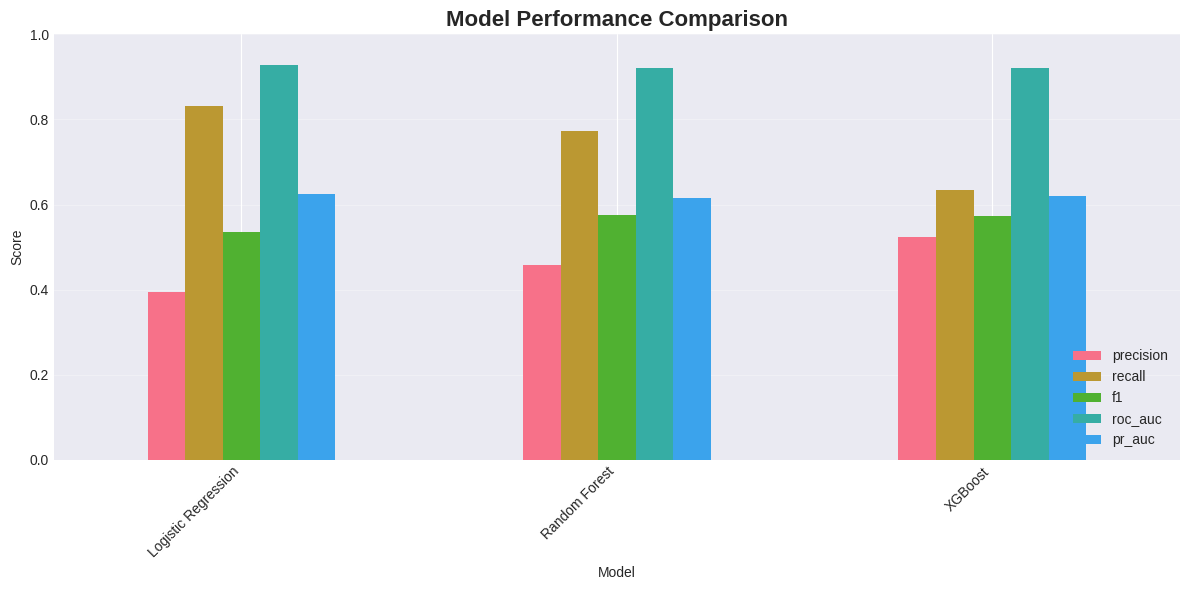

In [16]:
# Compare metrics across models
comparison_df = pd.DataFrame({
    'Logistic Regression': lr_metrics,
    'Random Forest': rf_metrics,
    'XGBoost': xgb_metrics
}).T

print("\nModel Comparison Summary:")
print(comparison_df)

# Visualize comparison
fig, ax = plt.subplots(figsize=(12, 6))
comparison_df.plot(kind='bar', ax=ax)
ax.set_title('Model Performance Comparison', fontsize=16, fontweight='bold')
ax.set_ylabel('Score')
ax.set_xlabel('Model')
ax.set_xticklabels(comparison_df.index, rotation=45, ha='right')
ax.legend(loc='lower right')
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

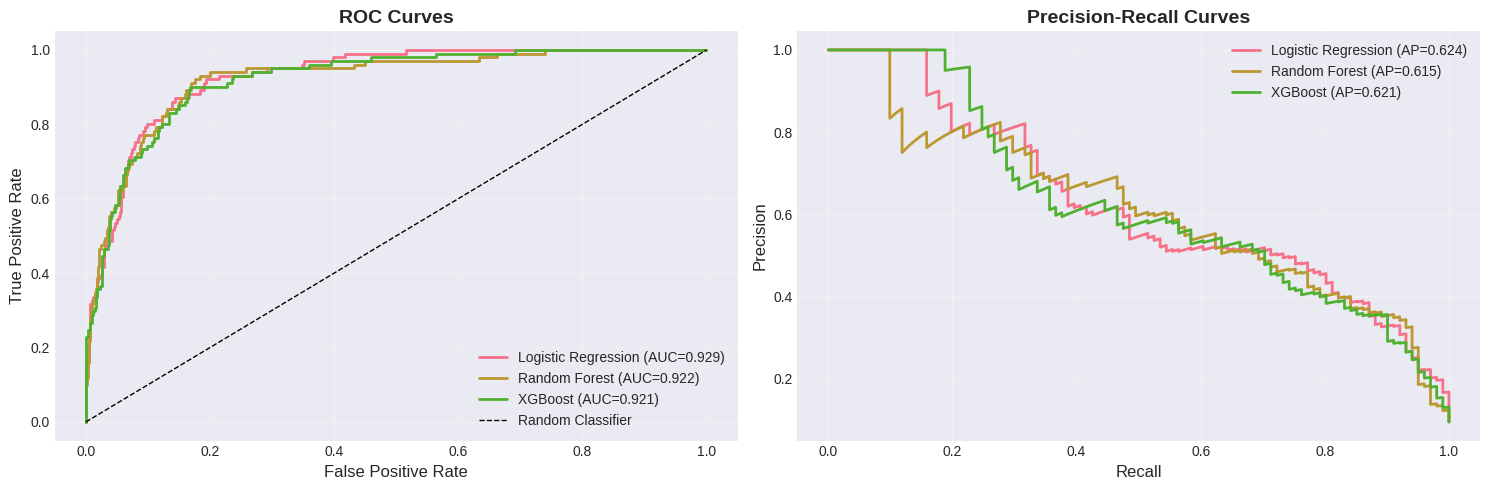

In [17]:
# Plot ROC curves for all models
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ROC Curve
models = [
    ('Logistic Regression', y_val_pred_proba_lr),
    ('Random Forest', y_val_pred_proba_rf),
    ('XGBoost', y_val_pred_proba_xgb)
]

for name, proba in models:
    fpr, tpr, _ = roc_curve(y_val, proba)
    auc = roc_auc_score(y_val, proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curves', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# Precision-Recall Curve
for name, proba in models:
    precision, recall, _ = precision_recall_curve(y_val, proba)
    ap = average_precision_score(y_val, proba)
    axes[1].plot(recall, precision, label=f'{name} (AP={ap:.3f})', linewidth=2)

axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curves', fontsize=14, fontweight='bold')
axes[1].legend(loc='best')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

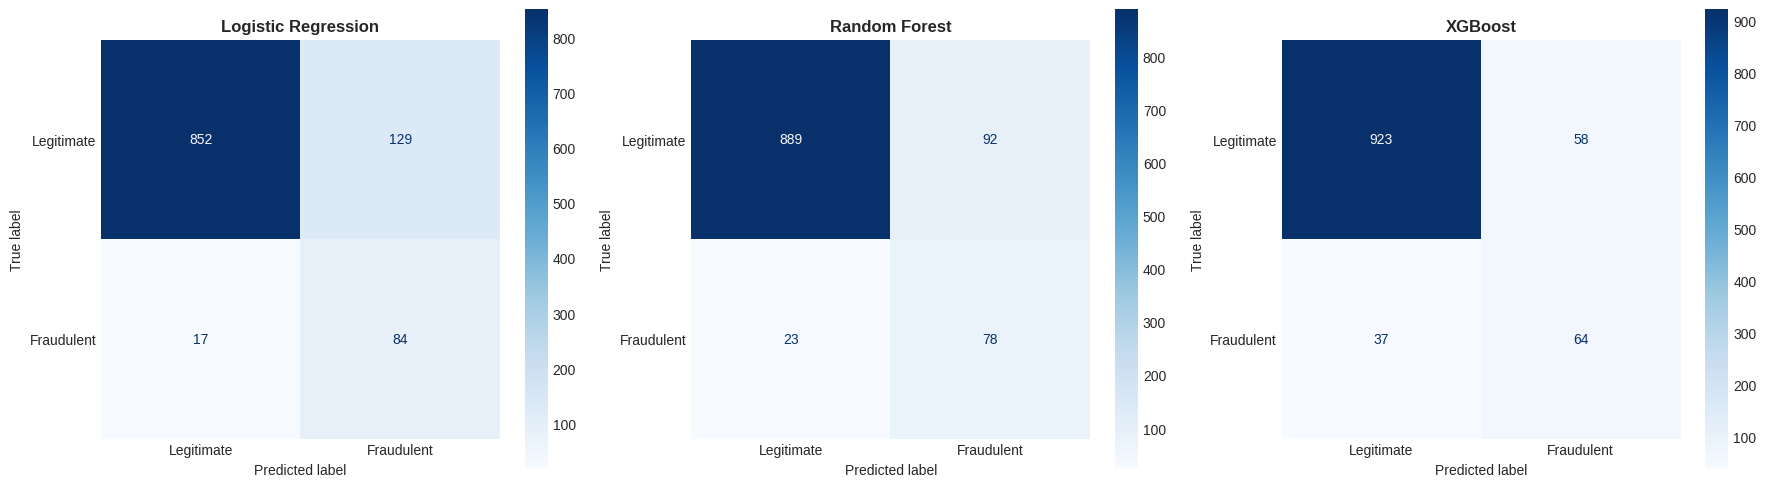

In [18]:
# Visualize confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_preds = [
    ('Logistic Regression', y_val_pred_lr),
    ('Random Forest', y_val_pred_rf),
    ('XGBoost', y_val_pred_xgb)
]

for idx, (name, pred) in enumerate(models_preds):
    cm = confusion_matrix(y_val, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate', 'Fraudulent'])
    disp.plot(ax=axes[idx], cmap='Blues', values_format='d')
    axes[idx].set_title(f'{name}', fontsize=12, fontweight='bold')
    axes[idx].grid(False)

plt.tight_layout()
plt.show()

## 11. Feature Importance Analysis

Understanding which features are most important helps:
1. **Interpretability**: Explain to investigators WHY a provider was flagged
2. **Trust**: Stakeholders can validate if the model uses reasonable signals
3. **Feature Engineering**: Identify which features to refine or expand

We'll look at feature importance from Random Forest and XGBoost.

Random Forest - Top 10 Most Important Features:
                  Feature  Importance
1              Total_Cost    0.140654
7           Inp_TotalCost    0.102249
20  Inp_NumUniquePatients    0.095539
10    Inp_AvgLengthOfStay    0.083366
6              Inp_Claims    0.070590
9             Inp_MaxCost    0.065336
0            Total_Claims    0.050703
11             Out_Claims    0.042851
4         Cost_PerPatient    0.039817
8             Inp_AvgCost    0.039299


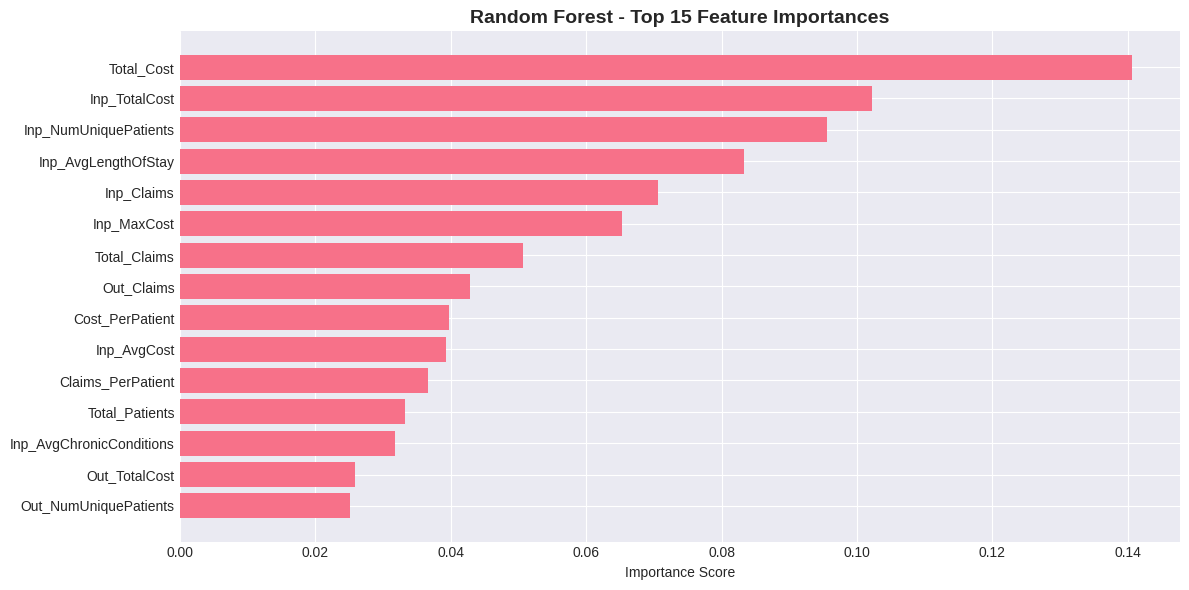

In [19]:
# Random Forest Feature Importance
rf_feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Random Forest - Top 10 Most Important Features:")
print(rf_feature_importance.head(10))

# Plot Random Forest feature importance
plt.figure(figsize=(12, 6))
plt.barh(rf_feature_importance['Feature'].head(15), rf_feature_importance['Importance'].head(15))
plt.xlabel('Importance Score')
plt.title('Random Forest - Top 15 Feature Importances', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


XGBoost - Top 10 Most Important Features:
                  Feature  Importance
1              Total_Cost    0.411204
10    Inp_AvgLengthOfStay    0.046976
3        AvgCost_PerClaim    0.033415
14     Inp_Out_ClaimRatio    0.032870
12          Out_TotalCost    0.032750
5       Claims_PerPatient    0.032300
6              Inp_Claims    0.031111
7           Inp_TotalCost    0.031051
9             Inp_MaxCost    0.029954
21  Out_NumUniquePatients    0.028663


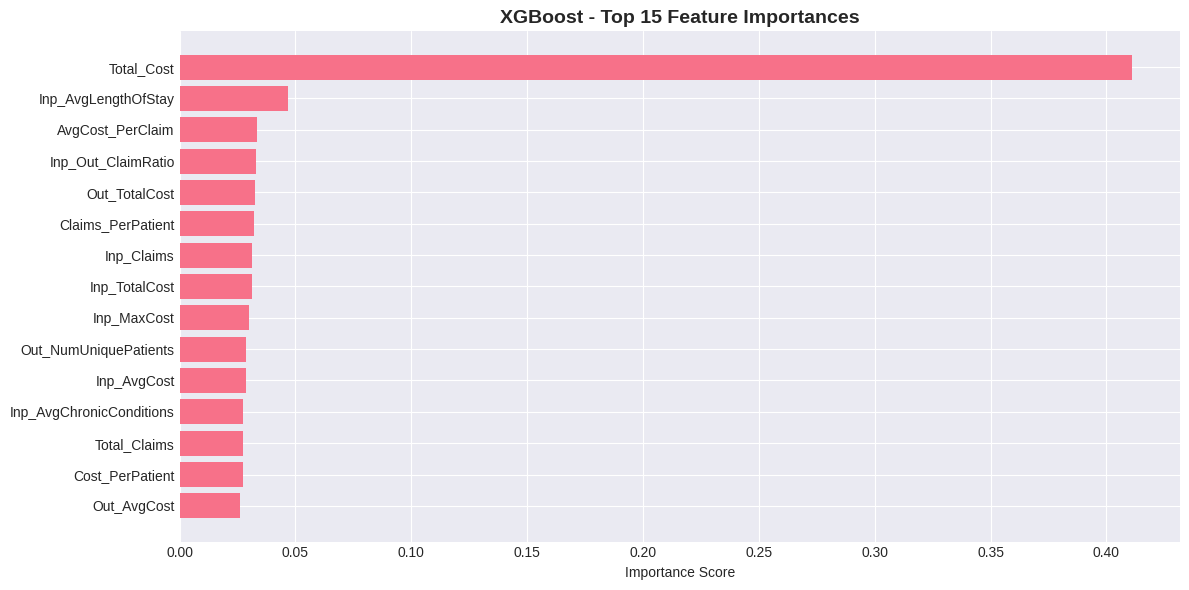

In [20]:
# XGBoost Feature Importance
xgb_feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nXGBoost - Top 10 Most Important Features:")
print(xgb_feature_importance.head(10))

# Plot XGBoost feature importance
plt.figure(figsize=(12, 6))
plt.barh(xgb_feature_importance['Feature'].head(15), xgb_feature_importance['Importance'].head(15))
plt.xlabel('Importance Score')
plt.title('XGBoost - Top 15 Feature Importances', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 12. Hyperparameter Tuning

**Hyperparameters** are settings we choose before training (not learned from data).

**GridSearchCV:**
- Tries all combinations of specified hyperparameters
- Uses cross-validation to evaluate each combination
- Selects the best combination based on chosen metric

We'll tune the best-performing model (likely XGBoost or Random Forest).

In [21]:
# Define parameter grid for XGBoost
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.1, 0.3],
    'scale_pos_weight': [scale_pos_weight]  # Keep our calculated value
}

print("Starting GridSearchCV for XGBoost...")
print(f"Total combinations to try: {3*3*3*1} = 27")
print("This may take a few minutes...\n")

# Create GridSearchCV
xgb_grid = GridSearchCV(
    XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'),
    param_grid=param_grid,
    cv=3,                          # 3-fold cross-validation
    scoring='f1',                  # Optimize for F1-score
    n_jobs=-1,                     # Use all CPU cores
    verbose=1
)

# Fit on training data
xgb_grid.fit(X_train_scaled, y_train)

print("\n✓ GridSearchCV completed!")
print(f"\nBest Parameters: {xgb_grid.best_params_}")
print(f"Best CV F1-Score: {xgb_grid.best_score_:.4f}")

Starting GridSearchCV for XGBoost...
Total combinations to try: 27 = 27
This may take a few minutes...

Fitting 3 folds for each of 27 candidates, totalling 81 fits

✓ GridSearchCV completed!

Best Parameters: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 150, 'scale_pos_weight': np.float64(9.677631578947368)}
Best CV F1-Score: 0.5939


In [22]:
# Evaluate tuned model on validation set
best_xgb = xgb_grid.best_estimator_
y_val_pred_tuned = best_xgb.predict(X_val_scaled)
y_val_pred_proba_tuned = best_xgb.predict_proba(X_val_scaled)[:, 1]

tuned_metrics = evaluate_model(y_val, y_val_pred_tuned, y_val_pred_proba_tuned, "Tuned XGBoost")


  Tuned XGBoost - Validation Set Performance

Precision:    0.5686  (Of predicted frauds, 56.9% are correct)
Recall:       0.5743  (Caught 57.4% of all fraudsters)
F1-Score:     0.5714  (Harmonic mean of Precision and Recall)
ROC-AUC:      0.9160  (Overall discriminative ability)
PR-AUC:       0.6123  (Performance on minority class)

Confusion Matrix:
[[937  44]
 [ 43  58]]

True Negatives (TN):  937 - Correctly identified legitimate providers
False Positives (FP): 44 - Legitimate providers wrongly flagged as fraud
False Negatives (FN): 43 - Fraudsters we MISSED (⚠️ critical!)
True Positives (TP):  58 - Correctly identified fraudsters

Detailed Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.96      0.96      0.96       981
  Fraudulent       0.57      0.57      0.57       101

    accuracy                           0.92      1082
   macro avg       0.76      0.76      0.76      1082
weighted avg       0.92      0.92      0.92      10

## 13. Error Analysis

Understanding model errors helps improve future iterations.

**False Positives (FP):** Legitimate providers flagged as fraud
- **Impact:** Wasted investigation resources, damaged reputation

**False Negatives (FN):** Fraudsters that were missed
- **Impact:** Continued fraud, financial losses

We'll analyze specific cases to understand why the model made these errors.

In [23]:
# Get the best model (tuned XGBoost)
best_model = best_xgb
y_pred_best = y_val_pred_tuned

# Identify errors
false_positives = np.where((y_val.values == 0) & (y_pred_best == 1))[0]
false_negatives = np.where((y_val.values == 1) & (y_pred_best == 0))[0]

print(f"Total False Positives: {len(false_positives)}")
print(f"Total False Negatives: {len(false_negatives)}")

# Analyze 3 False Positives
print("\n" + "="*80)
print("FALSE POSITIVE ANALYSIS - Legitimate Providers Flagged as Fraud")
print("="*80)

for i, idx in enumerate(false_positives[:3]):
    print(f"\nCase {i+1}:")
    print(f"Actual Label: Legitimate (0)")
    print(f"Predicted Label: Fraudulent (1)")
    print(f"Prediction Probability: {y_val_pred_proba_tuned[idx]:.3f}")
    print("\nFeature Values:")
    print(X_val_scaled.iloc[idx])
    print("-" * 80)

Total False Positives: 44
Total False Negatives: 43

FALSE POSITIVE ANALYSIS - Legitimate Providers Flagged as Fraud

Case 1:
Actual Label: Legitimate (0)
Predicted Label: Fraudulent (1)
Prediction Probability: 0.556

Feature Values:
Total_Claims                0.027907
Total_Cost                  0.743845
Total_Patients              0.177379
AvgCost_PerClaim            0.340442
Cost_PerPatient             0.388910
Claims_PerPatient          -0.276048
Inp_Claims                  1.069412
Inp_TotalCost               0.849302
Inp_AvgCost                 0.796256
Inp_MaxCost                 1.066138
Inp_AvgLengthOfStay         1.183144
Out_Claims                 -0.088486
Out_TotalCost              -0.177559
Out_AvgCost                -0.248027
Inp_Out_ClaimRatio         -0.099133
Inp_Out_CostRatio          -0.165164
Inp_AvgAge                  1.346733
Out_AvgAge                  0.327509
Inp_AvgChronicConditions    1.200195
Out_AvgChronicConditions    0.387710
Inp_NumUniquePatients     

In [24]:
# Analyze 3 False Negatives
print("\n" + "="*80)
print("FALSE NEGATIVE ANALYSIS - Fraudsters We Missed")
print("="*80)

for i, idx in enumerate(false_negatives[:3]):
    print(f"\nCase {i+1}:")
    print(f"Actual Label: Fraudulent (1)")
    print(f"Predicted Label: Legitimate (0)")
    print(f"Prediction Probability: {y_val_pred_proba_tuned[idx]:.3f}")
    print("\nFeature Values:")
    print(X_val_scaled.iloc[idx])
    print("-" * 80)


FALSE NEGATIVE ANALYSIS - Fraudsters We Missed

Case 1:
Actual Label: Fraudulent (1)
Predicted Label: Legitimate (0)
Prediction Probability: 0.030

Feature Values:
Total_Claims               -0.248045
Total_Cost                  0.044114
Total_Patients             -0.231835
AvgCost_PerClaim            0.314291
Cost_PerPatient             0.341136
Claims_PerPatient          -0.323550
Inp_Claims                  0.260710
Inp_TotalCost               0.141563
Inp_AvgCost                 0.698160
Inp_MaxCost                 0.266805
Inp_AvgLengthOfStay         0.616399
Out_Claims                 -0.283394
Out_TotalCost              -0.367584
Out_AvgCost                -0.748684
Inp_Out_ClaimRatio         -0.089964
Inp_Out_CostRatio          -0.164393
Inp_AvgAge                  1.267330
Out_AvgAge                  0.206075
Inp_AvgChronicConditions    1.143103
Out_AvgChronicConditions    0.310319
Inp_NumUniquePatients       0.099771
Out_NumUniquePatients      -0.263426
Has_HighInpatientCost

## 14. Final Model Selection and Test Set Evaluation

Based on validation performance, we select the best model.

**Now and only now, we evaluate on the test set** - data the model has NEVER seen.

This gives us an unbiased estimate of real-world performance.

In [25]:
# Select final model (tuned XGBoost)
final_model = best_xgb

print("Selected Final Model: Tuned XGBoost")
print(f"Best hyperparameters: {xgb_grid.best_params_}")

# Predict on test set
y_test_pred = final_model.predict(X_test_scaled)
y_test_pred_proba = final_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate on test set
test_metrics = evaluate_model(y_test, y_test_pred, y_test_pred_proba, "Final Model - Test Set")

Selected Final Model: Tuned XGBoost
Best hyperparameters: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 150, 'scale_pos_weight': np.float64(9.677631578947368)}

  Final Model - Test Set - Validation Set Performance

Precision:    0.6604  (Of predicted frauds, 66.0% are correct)
Recall:       0.6931  (Caught 69.3% of all fraudsters)
F1-Score:     0.6763  (Harmonic mean of Precision and Recall)
ROC-AUC:      0.9629  (Overall discriminative ability)
PR-AUC:       0.7388  (Performance on minority class)

Confusion Matrix:
[[945  36]
 [ 31  70]]

True Negatives (TN):  945 - Correctly identified legitimate providers
False Positives (FP): 36 - Legitimate providers wrongly flagged as fraud
False Negatives (FN): 31 - Fraudsters we MISSED (⚠️ critical!)
True Positives (TP):  70 - Correctly identified fraudsters

Detailed Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.97      0.96      0.97       981
  Fraudulent       0.66      0.69   

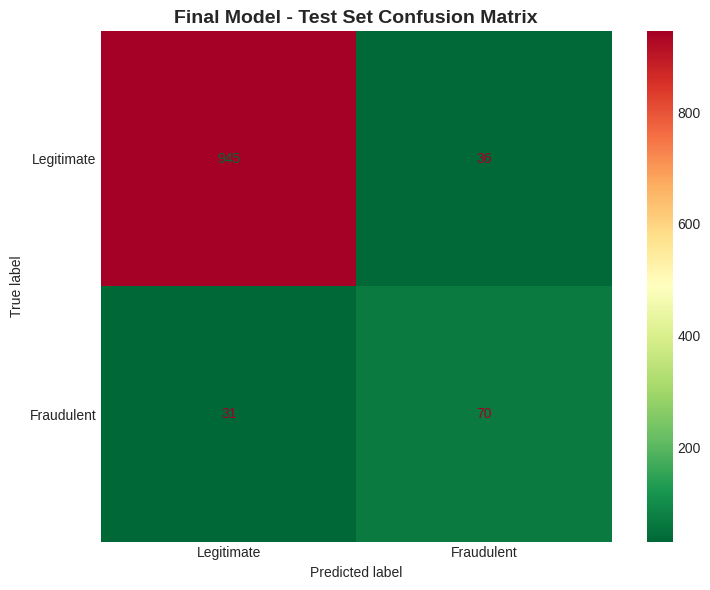

In [26]:
# Visualize test set confusion matrix
cm_test = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=['Legitimate', 'Fraudulent'])
disp.plot(ax=ax, cmap='RdYlGn_r', values_format='d')
ax.set_title('Final Model - Test Set Confusion Matrix', fontsize=14, fontweight='bold')
ax.grid(False)
plt.tight_layout()
plt.show()

## 15. Summary and Insights

Let's summarize our findings and provide business recommendations.

In [27]:
print("\n" + "="*80)
print(" "*25 + "PROJECT SUMMARY")
print("="*80)

print("\n1. DATASET:")
print(f"   - Total providers: {len(df)}")
print(f"   - Fraudulent: {y.sum()} ({y.sum()/len(y)*100:.1f}%)")
print(f"   - Features: {X.shape[1]}")

print("\n2. CLASS IMBALANCE HANDLING:")
print("   - Used SMOTE for Logistic Regression and Random Forest")
print("   - Used scale_pos_weight for XGBoost")

print("\n3. MODELS COMPARED:")
print("   - Logistic Regression (Baseline)")
print("   - Random Forest")
print("   - XGBoost (with hyperparameter tuning)")

print("\n4. BEST MODEL: Tuned XGBoost")
print(f"   Best parameters: {xgb_grid.best_params_}")

print("\n5. TEST SET PERFORMANCE:")
print(f"   - Precision:  {test_metrics['precision']:.4f}")
print(f"   - Recall:     {test_metrics['recall']:.4f}")
print(f"   - F1-Score:   {test_metrics['f1']:.4f}")
print(f"   - ROC-AUC:    {test_metrics['roc_auc']:.4f}")
print(f"   - PR-AUC:     {test_metrics['pr_auc']:.4f}")

print("\n6. KEY INSIGHTS:")
print("   - [Add your insights based on feature importance]")
print("   - [Discuss trade-offs between precision and recall]")
print("   - [Explain business impact]")

print("\n7. RECOMMENDATIONS:")
print("   - [Suggest investigation priorities]")
print("   - [Propose model deployment strategy]")
print("   - [Discuss potential improvements]")

print("\n" + "="*80)


                         PROJECT SUMMARY

1. DATASET:
   - Total providers: 5410
   - Fraudulent: 506 (9.4%)
   - Features: 24

2. CLASS IMBALANCE HANDLING:
   - Used SMOTE for Logistic Regression and Random Forest
   - Used scale_pos_weight for XGBoost

3. MODELS COMPARED:
   - Logistic Regression (Baseline)
   - Random Forest
   - XGBoost (with hyperparameter tuning)

4. BEST MODEL: Tuned XGBoost
   Best parameters: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 150, 'scale_pos_weight': np.float64(9.677631578947368)}

5. TEST SET PERFORMANCE:
   - Precision:  0.6604
   - Recall:     0.6931
   - F1-Score:   0.6763
   - ROC-AUC:    0.9629
   - PR-AUC:     0.7388

6. KEY INSIGHTS:
   - [Add your insights based on feature importance]
   - [Discuss trade-offs between precision and recall]
   - [Explain business impact]

7. RECOMMENDATIONS:
   - [Suggest investigation priorities]
   - [Propose model deployment strategy]
   - [Discuss potential improvements]



## 16. Save the Final Model

Save the trained model for future use in production or evaluation notebook.

In [28]:
import pickle

# Save the model
with open('final_fraud_detection_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

# Save the scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✓ Model and scaler saved successfully")
print("  - final_fraud_detection_model.pkl")
print("  - scaler.pkl")

✓ Model and scaler saved successfully
  - final_fraud_detection_model.pkl
  - scaler.pkl


## Next Steps

1. **Create 03_evaluation.ipynb** for deeper analysis:
   - Cost-benefit analysis
   - SHAP values for model interpretability
   - Business impact assessment
   - Threshold optimization

2. **Document findings** in technical report

3. **Prepare presentation** highlighting:
   - Problem and impact
   - Methodology
   - Results and recommendations